# Forecast with known-future exogenous variables

Use **`df`** for history (`unique_id`, `ds`, `y`, and exog columns in the past) and **`X_df`** for
known-future exog over the next `h` steps (no `y`). See [Exogenous variables](../exogenous-variables.md)
for the full API.

**Dataset:** panel built from fev-bench `epf_*` markets (BE, DE, FR, NP, PJM) with two covariates
per market, unified as `ex_1` and `ex_2`. Horizon length is **24 hours** (`h=24`).

**How it works:** Known-future exog means covariate values are available for each future `ds` you forecast.
In **`forecast()`**, pass them in **`X_df`** (`unique_id`, `ds`, exog columns; no `y`). History stays in
**`df`** with `y` and the same exog columns in the past. In **`cross_validation()`**, there is no `X_df`
argument, exog for the holdout window must appear in **`df`** (see [Exogenous variables](../exogenous-variables.md)).

**`exog_strategy`:** Default **`"auto"`** uses native exog when the checkpoint supports it; otherwise
FoundationForecast raises if horizon exog is provided. Set **`exog_strategy=False`** on models that should
ignore `X_df` (typical in a mixed **`FoundationForecast`**).

**Models in this example:** **Chronos-2**, **TimesFM 3.0**, and **T0** use native exog. **`Tafsut`** and
**Chronos-2-no-exog** use `exog_strategy=False` so the ensemble can pass **`X_df`** without error. Native
models support **`level`** with exog.

**Caveats:**
- Only **future-known dynamic** covariates are supported (values per future timestamp, not unknown at forecast time).
- Native exog depends on **`repo_id`** (e.g. Chronos **2**, TimesFM **3.0** — not every checkpoint in those families).
- **`X_df`** must have **exactly `h` rows per `unique_id`**, with `ds` continuing from history; misaligned or duplicate keys raise an error.
- **GPU** is recommended for Chronos-2 / TimesFM 3 / T0; the first run downloads weights from Hugging Face.

## Import libraries

In [1]:
import pandas as pd

from foundationforecast import FoundationForecast

/Users/azul/projects/foundationforecast/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:datasets:JAX version 0.7.1 available.


## Load the dataset

**History (`train.parquet`)** must include:
- `unique_id`: series identifier (string)
- `ds`: timestamp (datetime)
- `y`: target (float)
- exog columns through the observed period (`ex_1`, `ex_2` here)

**Horizon exog (`futr_exog.parquet`)** is loaded as **`X_df`** for **`forecast()`**:
- `unique_id`, `ds`, and exog columns for the next `h` steps
- **no `y`**

Load horizon exog into **`X_df`** for **`forecast()`**.

The pandas frequency is inferred from `ds` when `freq` is omitted.

In [2]:
DATA = "https://timecopilot.s3.amazonaws.com/public/data/electricity_price"
df = pd.read_parquet(f"{DATA}/train.parquet")
X_df = pd.read_parquet(f"{DATA}/futr_exog.parquet")

df.head()

,unique_id,ds,y,ex_1,ex_2
0,BE,2011-01-09 00:00:00,32.540001,63065.0,63000.0
1,BE,2011-01-09 01:00:00,21.549999,62715.0,58800.0
2,BE,2011-01-09 02:00:00,15.710000,61952.0,58500.0
3,BE,2011-01-09 03:00:00,10.580000,59262.0,54300.0
4,BE,2011-01-09 04:00:00,10.320000,56883.0,51900.0


In [3]:
X_df.head()

,unique_id,ds,ex_1,ex_2
0,BE,2016-12-12 00:00:00,56275.0,64188.0
1,BE,2016-12-12 01:00:00,54866.0,61076.0
2,BE,2016-12-12 02:00:00,56534.0,61246.0
3,BE,2016-12-12 03:00:00,56042.0,58082.0
4,BE,2016-12-12 04:00:00,56114.0,56397.0


## Plot the data

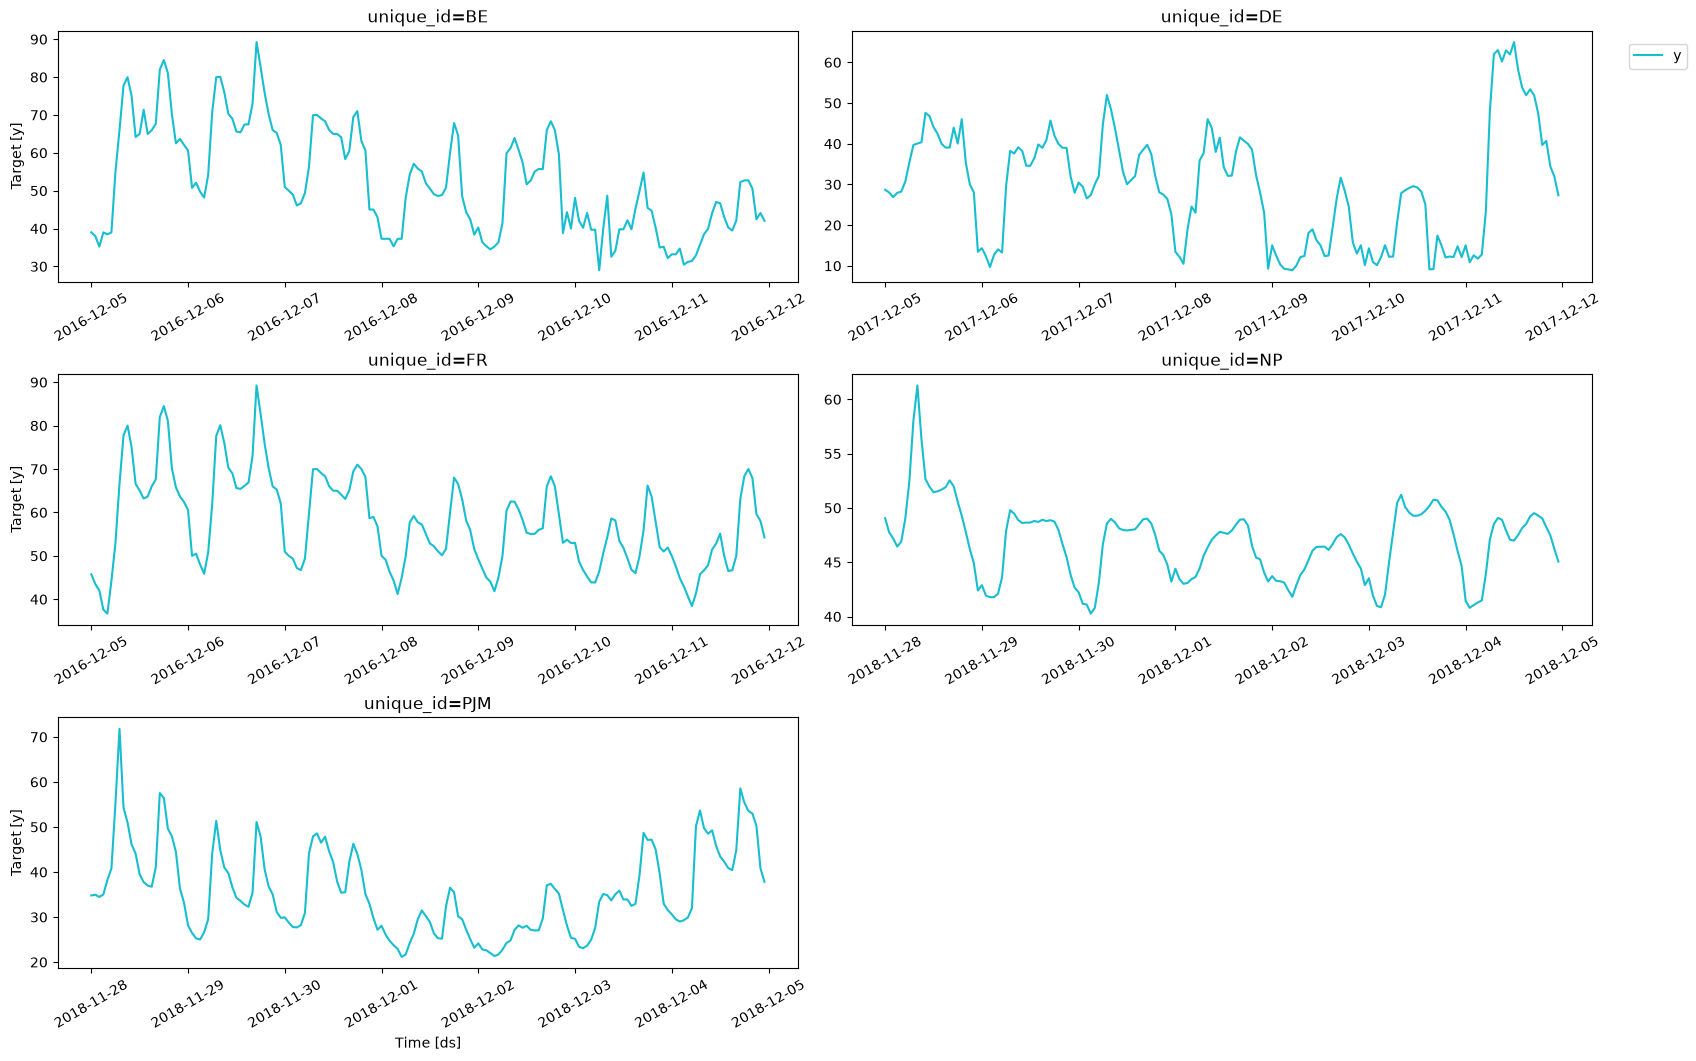

In [4]:
FoundationForecast.plot(df, max_insample_length=24 * 7)

## Import the models

In [5]:
from foundationforecast.models import Chronos, T0, Tafsut, TimesFM

## Create a FoundationForecast

We run several models in one call. Each model has an **`alias`** so forecast columns are easy to tell apart.

**Chronos-2**, **TimesFM-3**, and **t0-beta** use default `exog_strategy="auto"` and consume **`X_df`** when you forecast.
**Tafsut** and **Chronos-2-no-exog** set `exog_strategy=False` so they still run univariately when they receives **`X_df`**.

In [6]:
models = [
    Tafsut(alias="Tafsut", exog_strategy=False),
    TimesFM(repo_id="google/timesfm-3.0-pytorch", alias="TimesFM-3"),
    T0(repo_id="theforecastingcompany/t0-beta", alias="t0-beta"),
    Chronos(repo_id="amazon/chronos-2", alias="Chronos-2"),
    Chronos(repo_id="amazon/chronos-2", alias="Chronos-2-no-exog", exog_strategy=False),
]

ff = FoundationForecast(models=models)

## Cross validation

`cross_validation()` evaluates models on rolling windows. When using exog, ensure **`df`** includes exog columns along with **`y`**.

Models with `exog_strategy=False` ignore exog columns and fit univariate baselines on each window.

In [7]:
level = [80, 90]
h = 24

cv_df = ff.cross_validation(
    df=df,
    h=h,
    level=level,
)

0it [00:00, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.78s/it]
1it [00:03,  3.15s/it]
0it [00:00, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
100%|██████████| 1/1 [00:02<00:00,  2.04s/it]
1it [00:05,  5.75s/it]
100%|██████████| 1/1 [00:01<00:00,  1.44s/it]
1it [00:05,  5.25s/it]
Loading weights: 100%|██████████| 170/170 [00:00<00:00, 6564.46it/s]
1it [00:04,  4.66s/it]
100%|██████████| 1/1 [00:01<00:00,  1.03s/it]
1it [00:01,  1.06s/it]


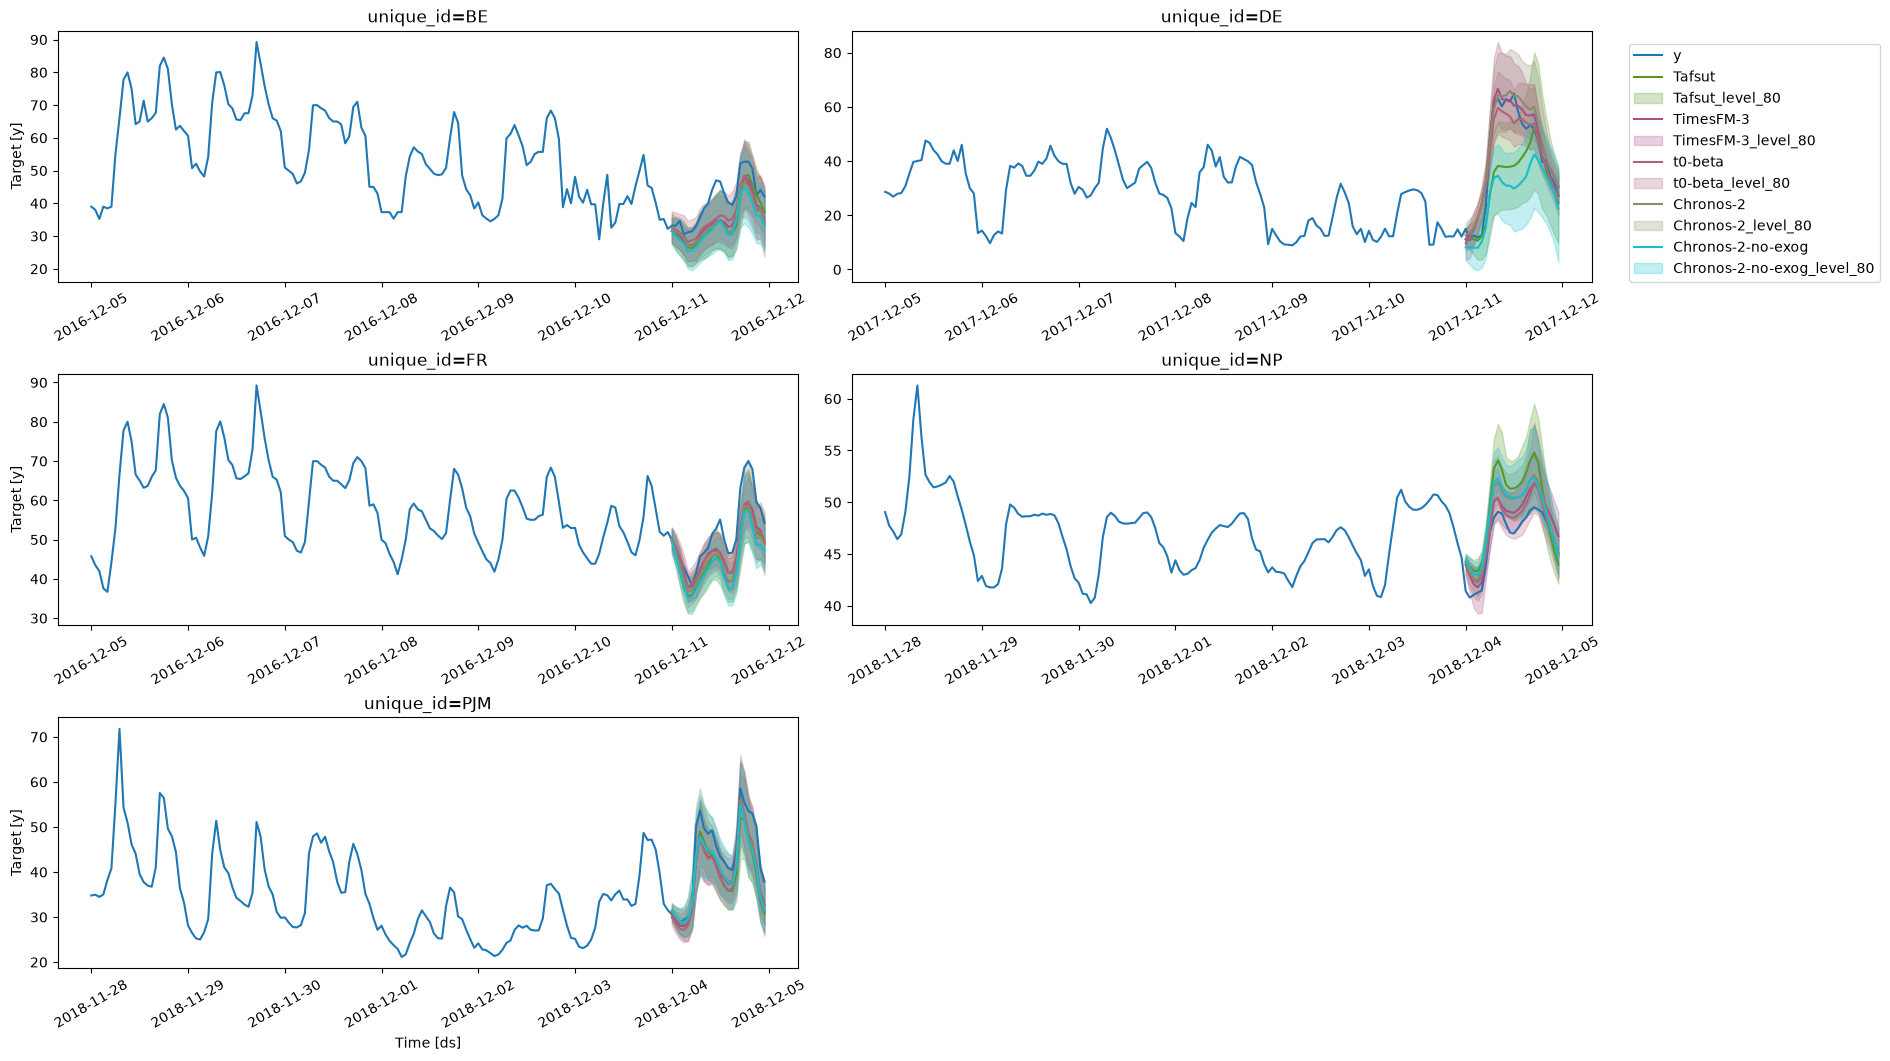

In [8]:
ff.plot(
    df,
    cv_df.drop(columns=["cutoff", "y"]),
    level=[80],
    max_insample_length=24 * 7,
)

In [9]:
cv_df.head()

,unique_id,ds,cutoff,y,Tafsut,Tafsut-lo-80,Tafsut-hi-80,Tafsut-lo-90,Tafsut-hi-90,TimesFM-3,...,Chronos-2,Chronos-2-lo-80,Chronos-2-hi-80,Chronos-2-lo-90,Chronos-2-hi-90,Chronos-2-no-exog,Chronos-2-no-exog-lo-80,Chronos-2-no-exog-hi-80,Chronos-2-no-exog-lo-90,Chronos-2-no-exog-hi-90
0,BE,2016-12-11 00:00:00,2016-12-10 23:00:00,33.200001,31.669380,28.051510,35.548500,28.051510,35.548500,31.545292,...,32.425201,28.058277,36.865078,26.096519,38.751842,31.511875,27.488224,35.715389,25.807266,37.568810
1,BE,2016-12-11 01:00:00,2016-12-10 23:00:00,33.200001,30.402401,25.787025,35.776043,25.787025,35.776043,30.904312,...,31.214901,26.553318,35.934124,24.536396,37.829185,29.953289,25.570141,34.657833,23.853813,36.584637
2,BE,2016-12-11 02:00:00,2016-12-10 23:00:00,34.700001,28.962326,24.194904,34.942524,24.194904,34.942524,30.139259,...,30.686020,25.748207,35.666660,23.632435,37.629265,28.972088,24.086269,34.092484,22.213009,36.167492
3,BE,2016-12-11 03:00:00,2016-12-10 23:00:00,30.459999,27.788616,22.765446,33.787159,22.765446,33.787159,28.346500,...,29.452126,23.877048,34.600399,21.456821,36.538319,27.753559,22.349266,33.118782,20.193588,35.195053
4,BE,2016-12-11 04:00:00,2016-12-10 23:00:00,31.200001,26.644466,21.311480,32.696373,21.311480,32.696373,27.079426,...,26.980789,20.742443,32.536556,18.127014,34.714508,25.436211,20.134090,31.095709,18.014044,33.384060


## Evaluation

We aggregate **MASE** and **scaled CRPS** across series and windows with `utilsforecast`. **`train_df=df`**
uses history only for scaling. Interval scores use the same **`level`** list as in cross-validation.

In [10]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

In [11]:
eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df,
    metrics=[partial(mase, seasonality=24), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.round(3).sort_values(by="mase")

metric,mase,scaled_crps
t0-beta,0.571,0.028
TimesFM-3,0.588,0.030
Chronos-2,0.691,0.031
Tafsut,0.961,0.050
Chronos-2-no-exog,1.015,0.063


## Forecast

You can specify:
- **`h`**: forecast horizon (must match the number of rows per series in **`X_df`**)
- **`X_df`**: horizon exog (from `futr_exog.parquet` above)
- **`level`**: prediction interval levels

`FoundationForecast` forwards **`X_df`** to exog-capable models; others follow their **`exog_strategy`**.

In [12]:
fcst_df = ff.forecast(df, h=24, X_df=X_df, level=[80, 90])

100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


## Plot forecast

Plot insample history and out-of-sample forecasts. Models that ignored exog appear as univariate baselines for the same horizon.

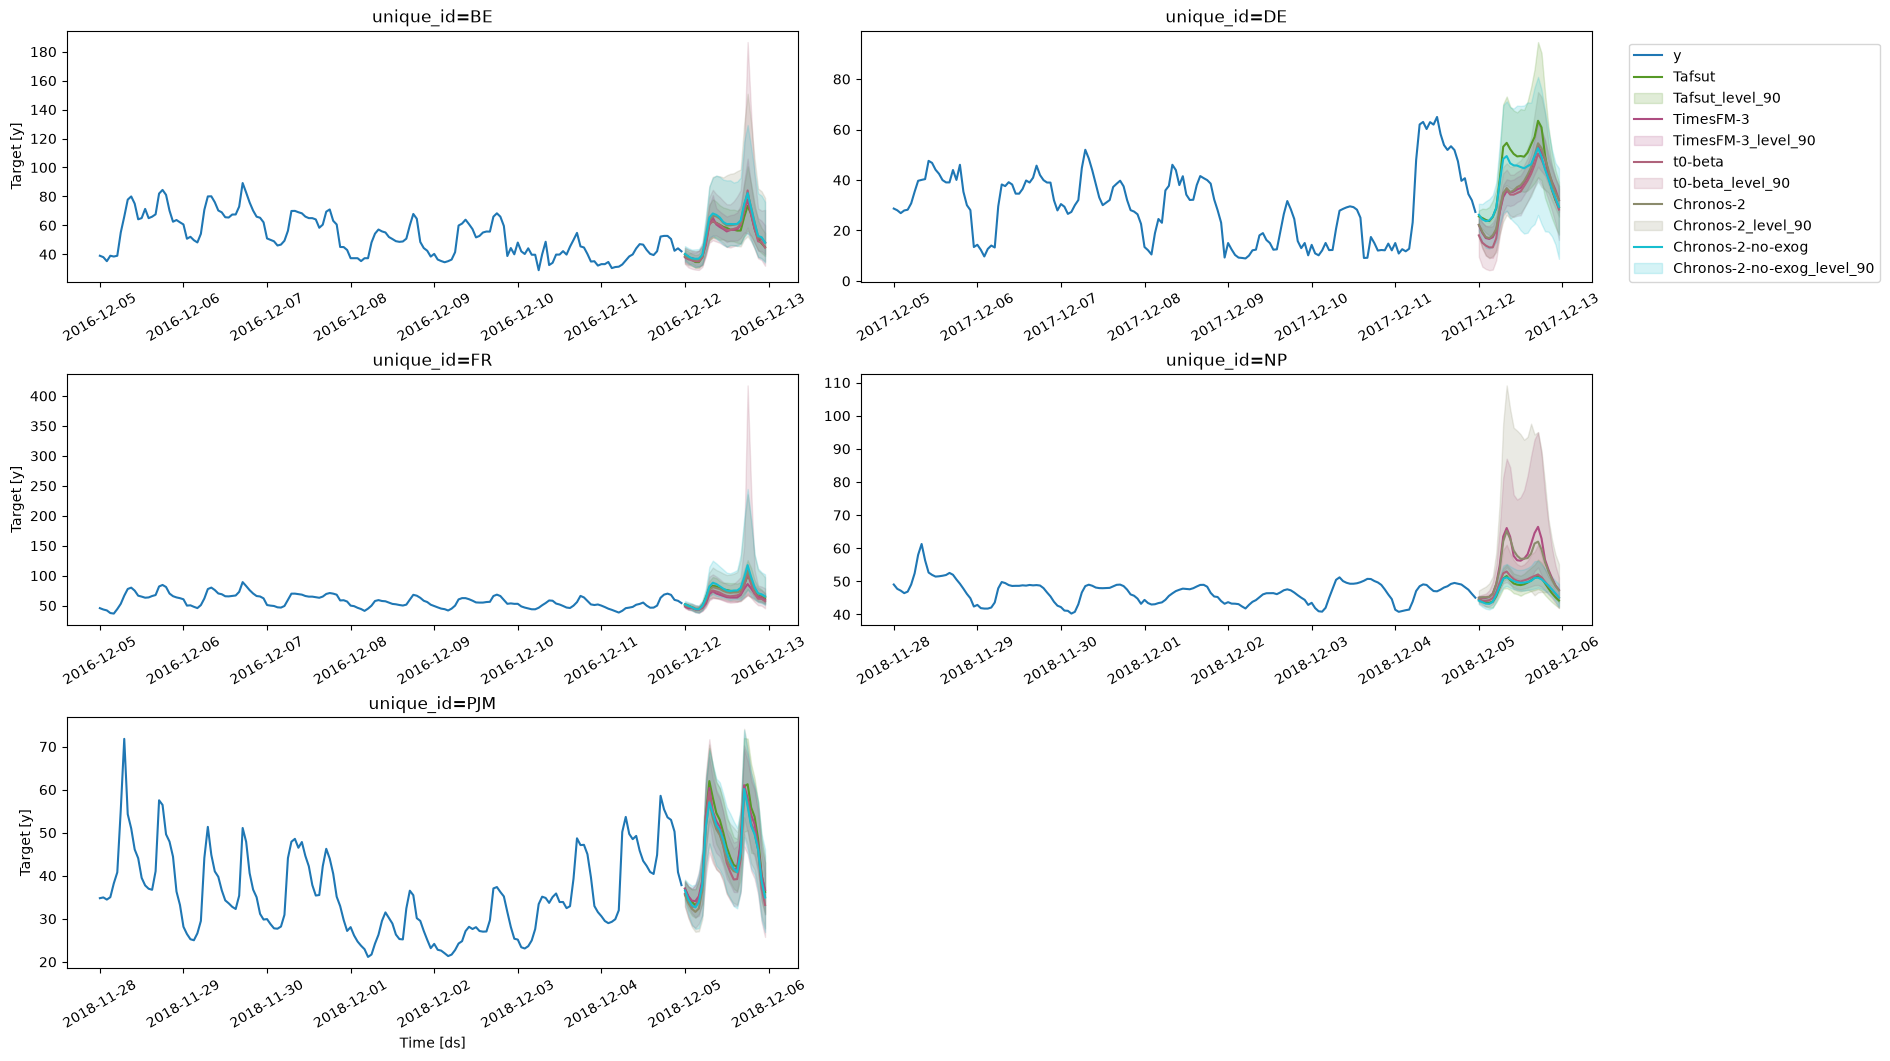

In [13]:
ff.plot(df, fcst_df, max_insample_length=24 * 7, level=[90])